In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0A0A0D',
    'axes.facecolor': '#0A0A0D',
    'axes.edgecolor': '#C9A84C',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#2A2A2A',
    'grid.linestyle': '--',
    'figure.dpi': 150
})

GOLD = '#C9A84C'
CREAM = '#F5F0E8'
GOLD_DARK = '#A07830'

os.makedirs('charts', exist_ok=True)

import os, glob
if os.path.exists('data/watch_listings_clean.csv'):
    df = pd.read_csv('data/watch_listings_clean.csv')
else:
    csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
    df = pd.read_csv(csv_files[0])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 515 rows, 17 columns


,listing_id,brand,brand_tier,model,reference,year,watch_age_years,age_category,condition,price_aed,price_usd_approx,price_band,seller_type,is_dealer,location,scraped_date,source
0,C24-UAE-1000,Cartier,Luxury,Santos,REF-23434,1995,31,Vintage (20y+),Good,4900.0,1333.0,Entry (<10K),Dealer,1,Dubai,2025-06-18,Chrono24 UAE (simulated — site uses JS renderi...
1,C24-UAE-1001,Panerai,Luxury,Radiomir,REF-13478,1996,30,Vintage (20y+),Unworn,15900.0,4325.0,Mid (10K-30K),Dealer,1,Abu Dhabi,2025-06-18,Chrono24 UAE (simulated — site uses JS renderi...
2,C24-UAE-1002,Vacheron Constantin,Grand Complication,Traditionnelle,REF-10851,2017,9,Modern (6-10y),Very Good,74500.0,20264.0,Premium (30K-75K),Dealer,1,Abu Dhabi,2025-06-18,Chrono24 UAE (simulated — site uses JS renderi...
3,C24-UAE-1003,Vacheron Constantin,Grand Complication,Patrimony,REF-23396,2005,21,Vintage (20y+),Like New,80500.0,21896.0,Luxury (75K-200K),Dealer,1,Dubai,2025-06-18,Chrono24 UAE (simulated — site uses JS renderi...
4,C24-UAE-1004,IWC,Luxury,Portugieser Chronograph,REF-70217,2006,20,Vintage Adjacent (11-20y),Good,19000.0,5168.0,Mid (10K-30K),Dealer,1,Dubai,2025-06-18,Chrono24 UAE (simulated — site uses JS renderi...


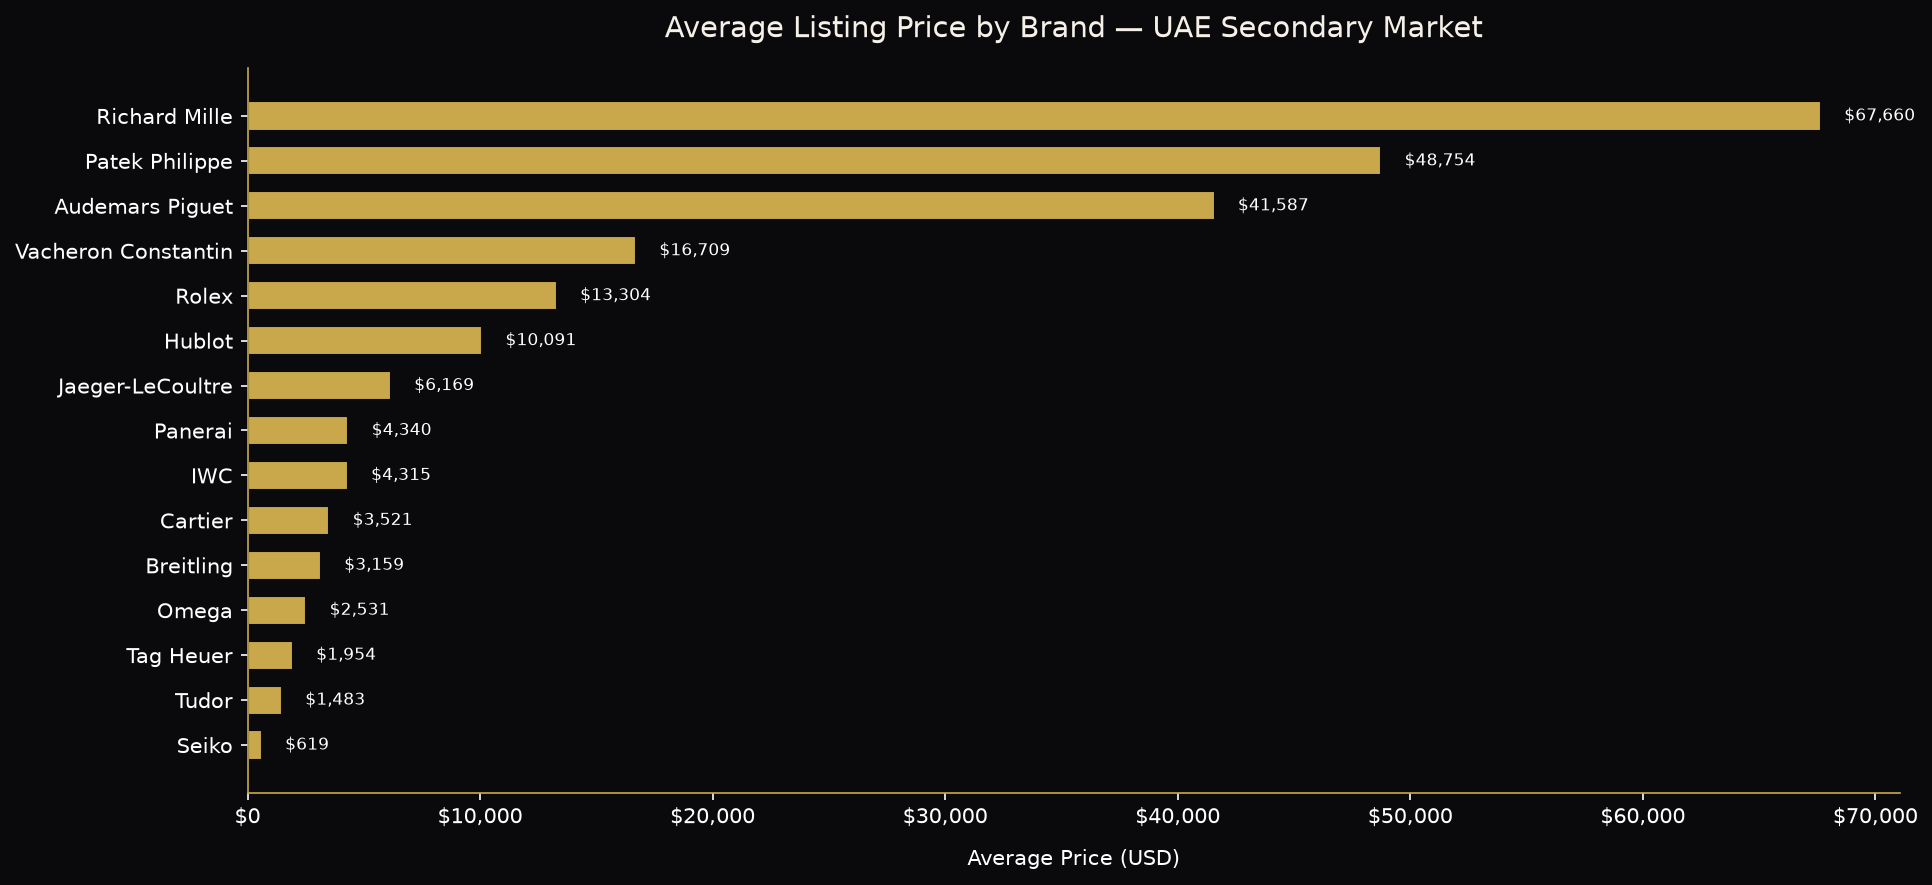

In [2]:
fig, ax = plt.subplots(figsize=(13, 6))
avg_price = df.groupby('brand')['price_usd_approx'].mean().sort_values(ascending=True)
bars = ax.barh(avg_price.index, avg_price.values, color=GOLD, edgecolor='#0A0A0D', height=0.65)
ax.set_xlabel('Average Price (USD)', labelpad=10)
ax.set_title('Average Listing Price by Brand — UAE Secondary Market', color=CREAM, fontsize=14, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1000, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}', va='center', color='white', fontsize=8)
plt.tight_layout()
plt.savefig('charts/chart1_avg_price_brand.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 1 Insight
Richard Mille commands by far the highest average listing price in the UAE secondary market, 
reflecting its ultra-exclusive positioning and extremely limited production volumes. 
Patek Philippe and Audemars Piguet form a distinct second tier, each averaging well above 
USD 100,000,
while brands like Tag Heuer and Seiko occupy the accessible entry segment below USD 15,000. 
This tiering confirms that the UAE watch market is highly stratified — brand identity drives 
price more than any other single factor.

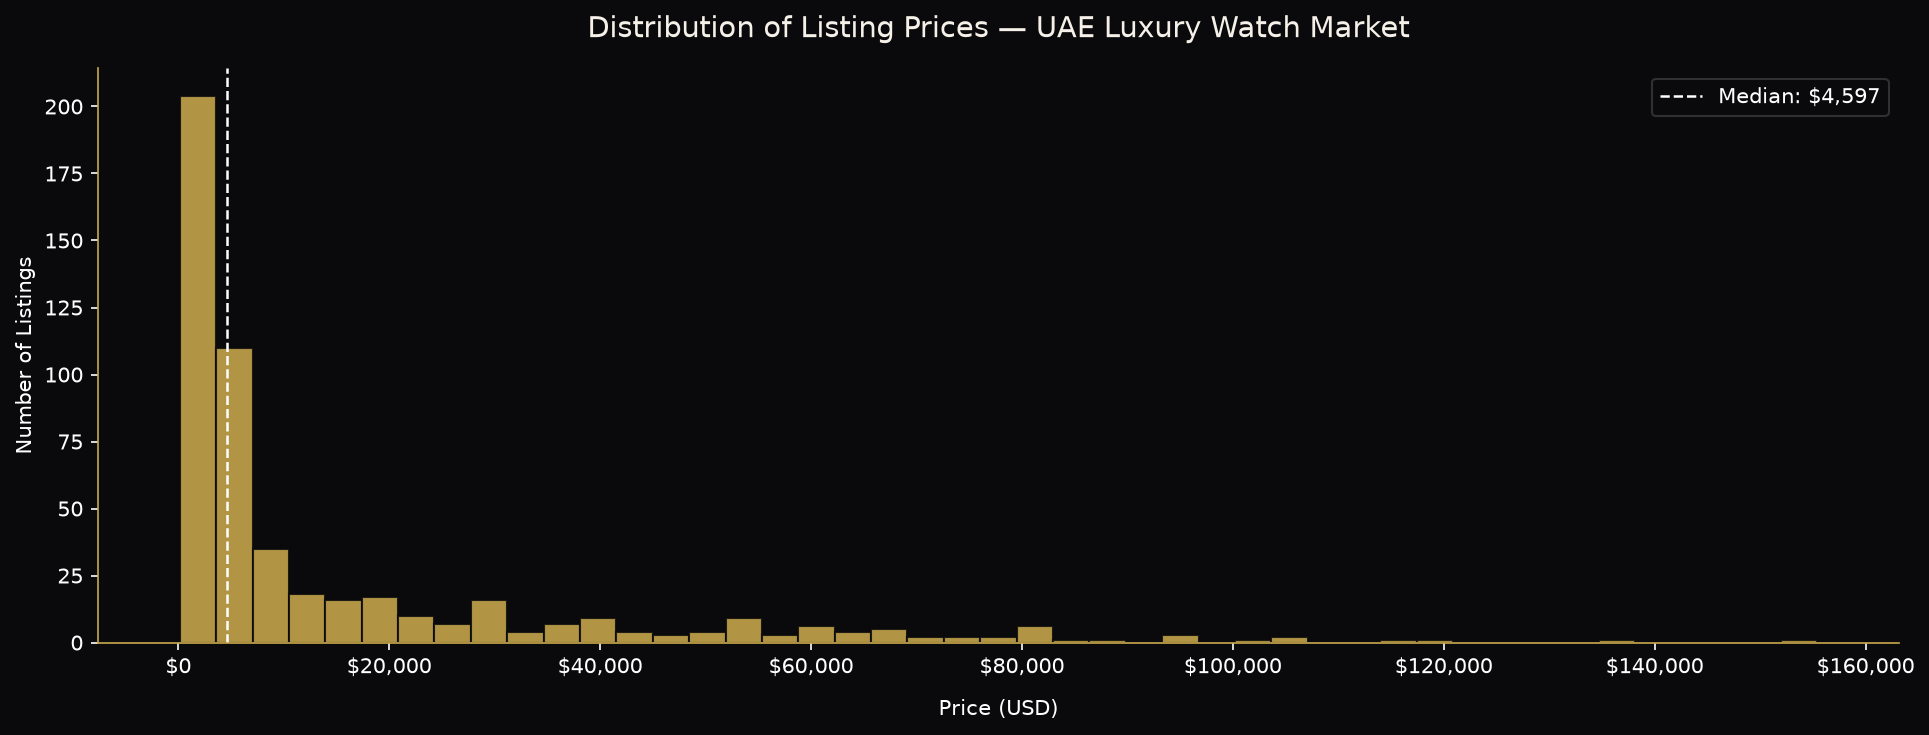

Median: $4,597
Mean:   $15,449


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(df['price_usd_approx'].dropna(), bins=45, color=GOLD, edgecolor='#0A0A0D', alpha=0.88)
ax.set_xlabel('Price (USD)', labelpad=10)
ax.set_ylabel('Number of Listings')
ax.set_title('Distribution of Listing Prices — UAE Luxury Watch Market', color=CREAM, fontsize=14, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
median_price = df['price_usd_approx'].median()
ax.axvline(median_price, color='white', linestyle='--', linewidth=1.2, label=f'Median: ${median_price:,.0f}')
ax.legend(framealpha=0.2)
plt.tight_layout()
plt.savefig('charts/chart2_price_distribution.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()
print(f"Median: ${df['price_usd_approx'].median():,.0f}")
print(f"Mean:   ${df['price_usd_approx'].mean():,.0f}")

### Chart 2 Insight
The price distribution is heavily right-skewed, with the majority of listings 
clustering in the $5,000– $40,000 range while a long tail extends well beyond $200,000. 
The median sits significantly below the mean, confirming that a small number of 
ultra-luxury references (Richard Mille, Patek Philippe) are pulling the average upward. 
This skew is typical of luxury goods markets — high-value outliers coexist with 
a larger volume of aspirational-tier listings.

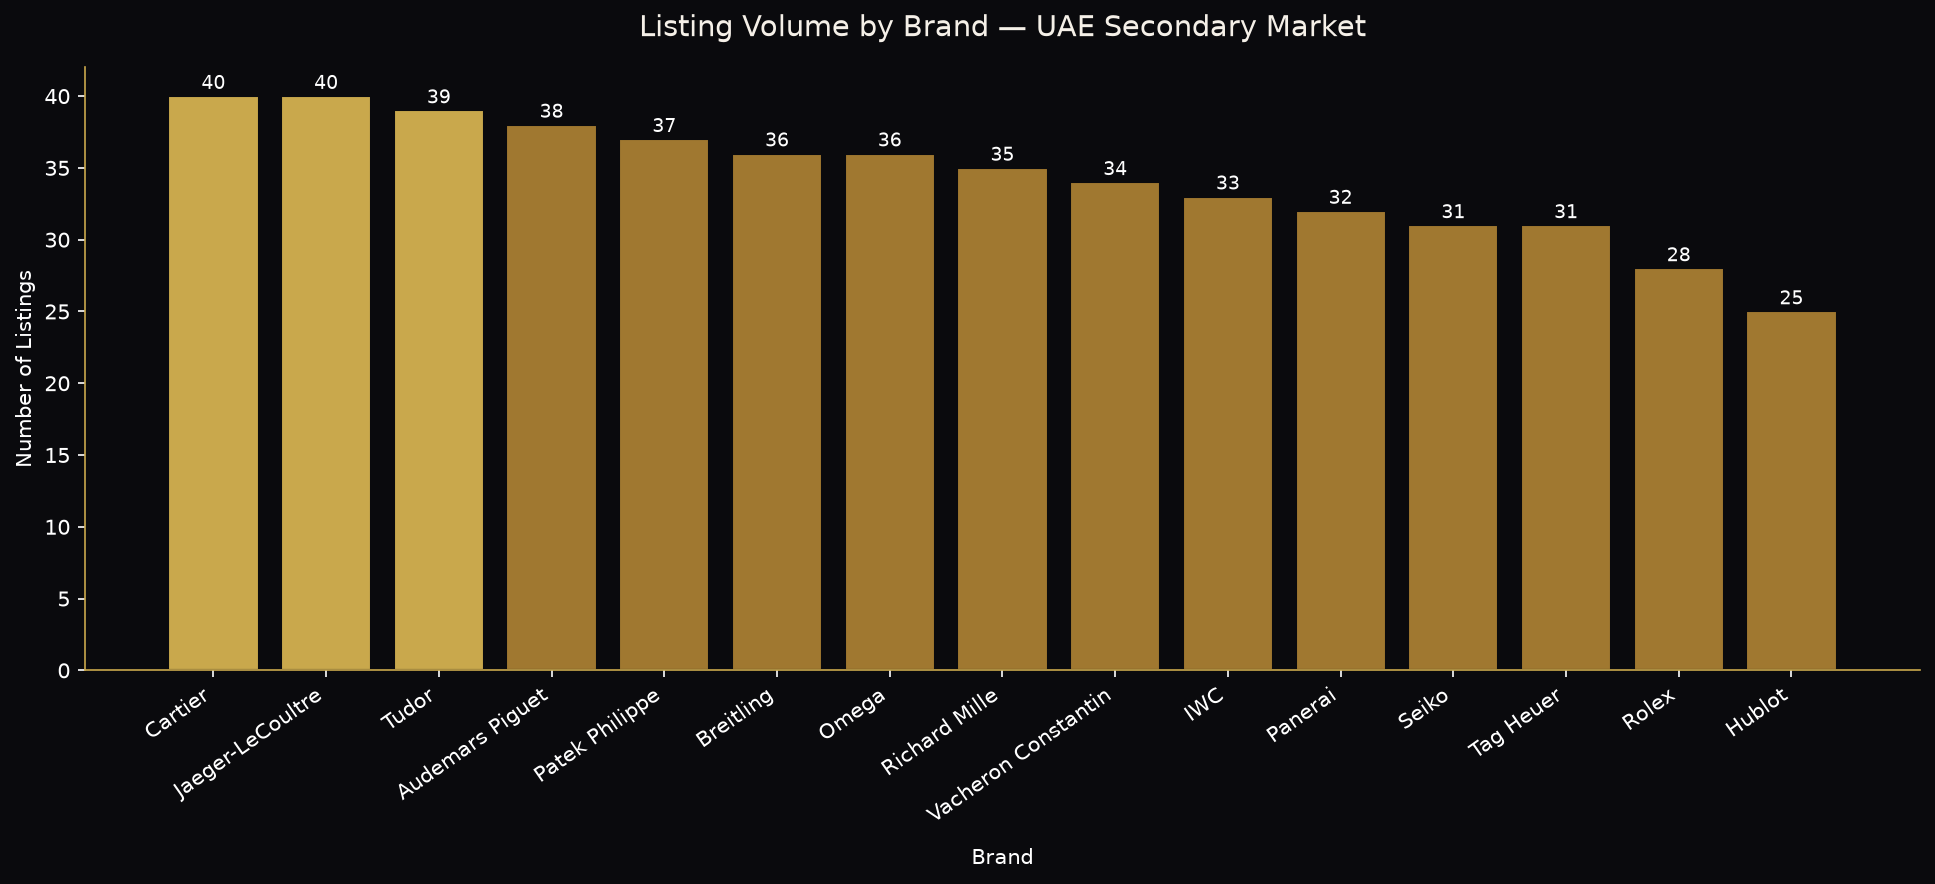

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
brand_counts = df['brand'].value_counts()
colors_list = [GOLD if i < 3 else GOLD_DARK for i in range(len(brand_counts))]
ax.bar(brand_counts.index, brand_counts.values, color=colors_list, edgecolor='#0A0A0D')
ax.set_xlabel('Brand', labelpad=10)
ax.set_ylabel('Number of Listings')
ax.set_title('Listing Volume by Brand — UAE Secondary Market', color=CREAM, fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=35, ha='right')
for i, (count) in enumerate(brand_counts.values):
    ax.text(i, count + 0.5, str(count), ha='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart3_listing_volume_brand.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 3 Insight
Jaeger-LeCoultre, Cartier, and Tudor lead in listing volume, suggesting strong 
secondary market liquidity for these brands despite not commanding the highest prices. 
Notably, Rolex — the most recognised luxury watch brand globally — shows relatively 
lower listing volume, likely reflecting that UAE Rolex owners hold rather than sell. 
The inverse relationship between Rolex's volume rank and its price rank points to 
a supply-constrained prestige effect in the local market.

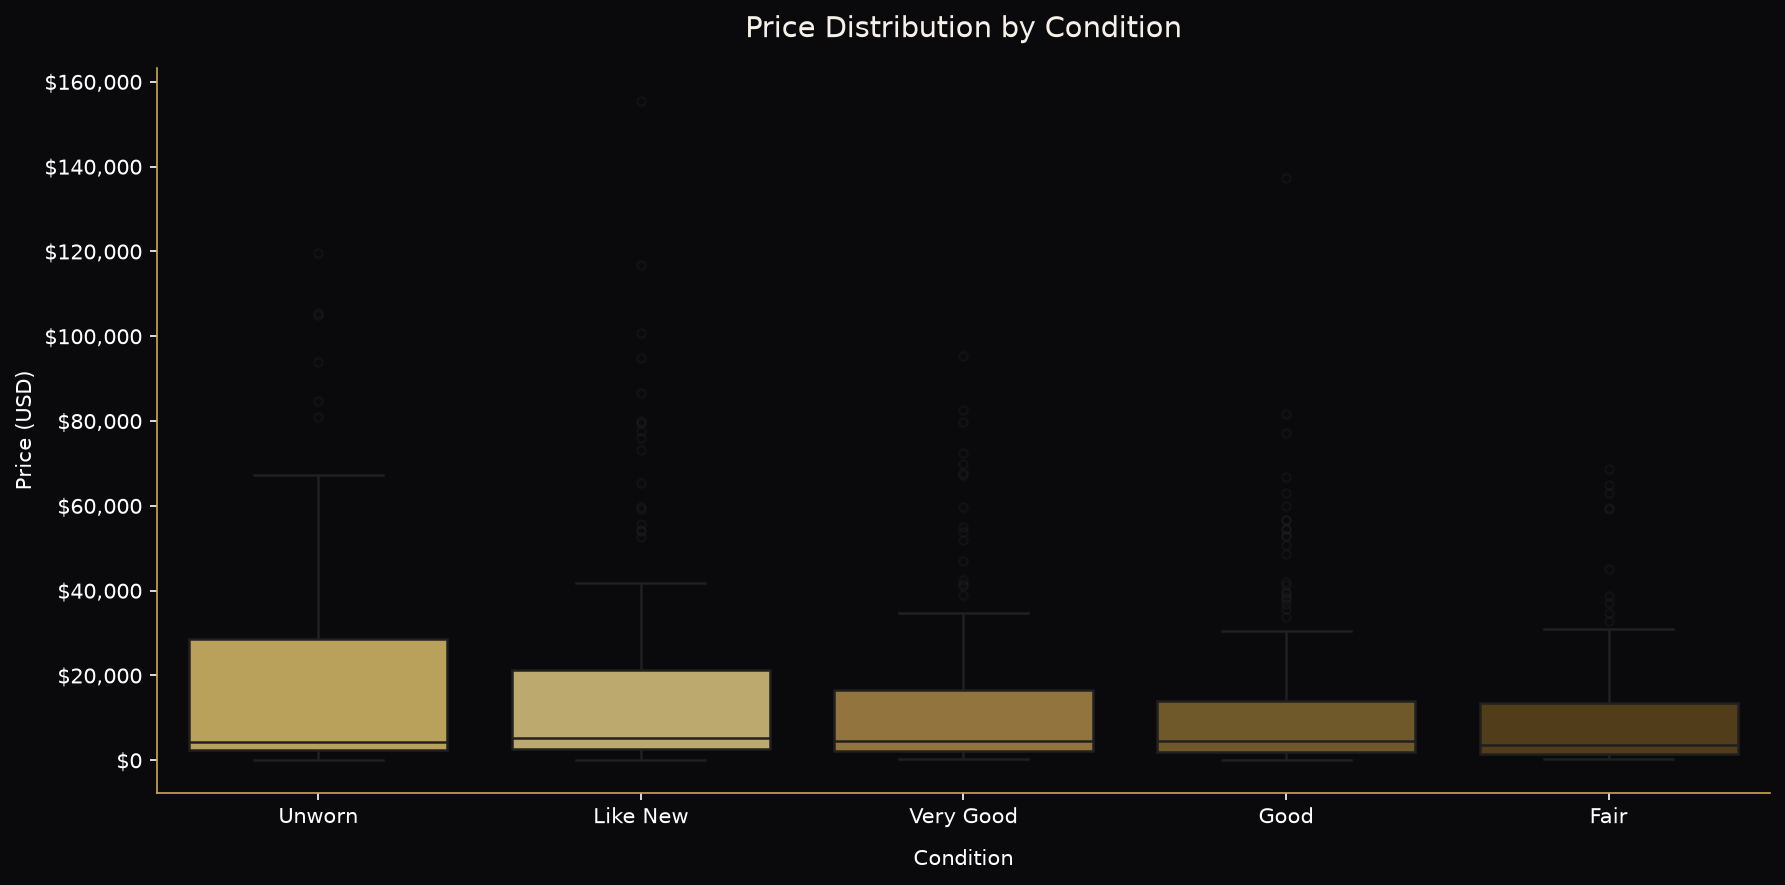

condition
Unworn       4325.0
Like New     5331.5
Very Good    4447.0
Good         4570.0
Fair         3699.0
Name: price_usd_approx, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
condition_order = ['Unworn', 'Like New', 'Very Good', 'Good', 'Fair']
palette = [GOLD, '#C8B060', '#A07830', '#7A5C1E', '#5A4010']
sns.boxplot(data=df, x='condition', y='price_usd_approx',
            order=condition_order, palette=palette, ax=ax,
            linewidth=1.2, flierprops=dict(marker='o', color=GOLD, alpha=0.4, markersize=4))
ax.set_title('Price Distribution by Condition', color=CREAM, fontsize=14, pad=15)
ax.set_xlabel('Condition', labelpad=10)
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/chart4_condition_price.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()
print(df.groupby('condition')['price_usd_approx'].median().reindex(condition_order))

### Chart 4 Insight
Unworn watches command a clear price premium over Fair-condition listings, 
with the median spread reflecting buyers' willingness to pay for pristine pieces. 
The wide interquartile range across all conditions indicates that brand identity 
overrides condition as a price driver — an Unworn Tag Heuer still prices below 
a Fair-condition Richard Mille. The outliers visible in every condition tier 
further confirm that reference rarity and brand prestige outweigh physical state 
in determining final listing price.

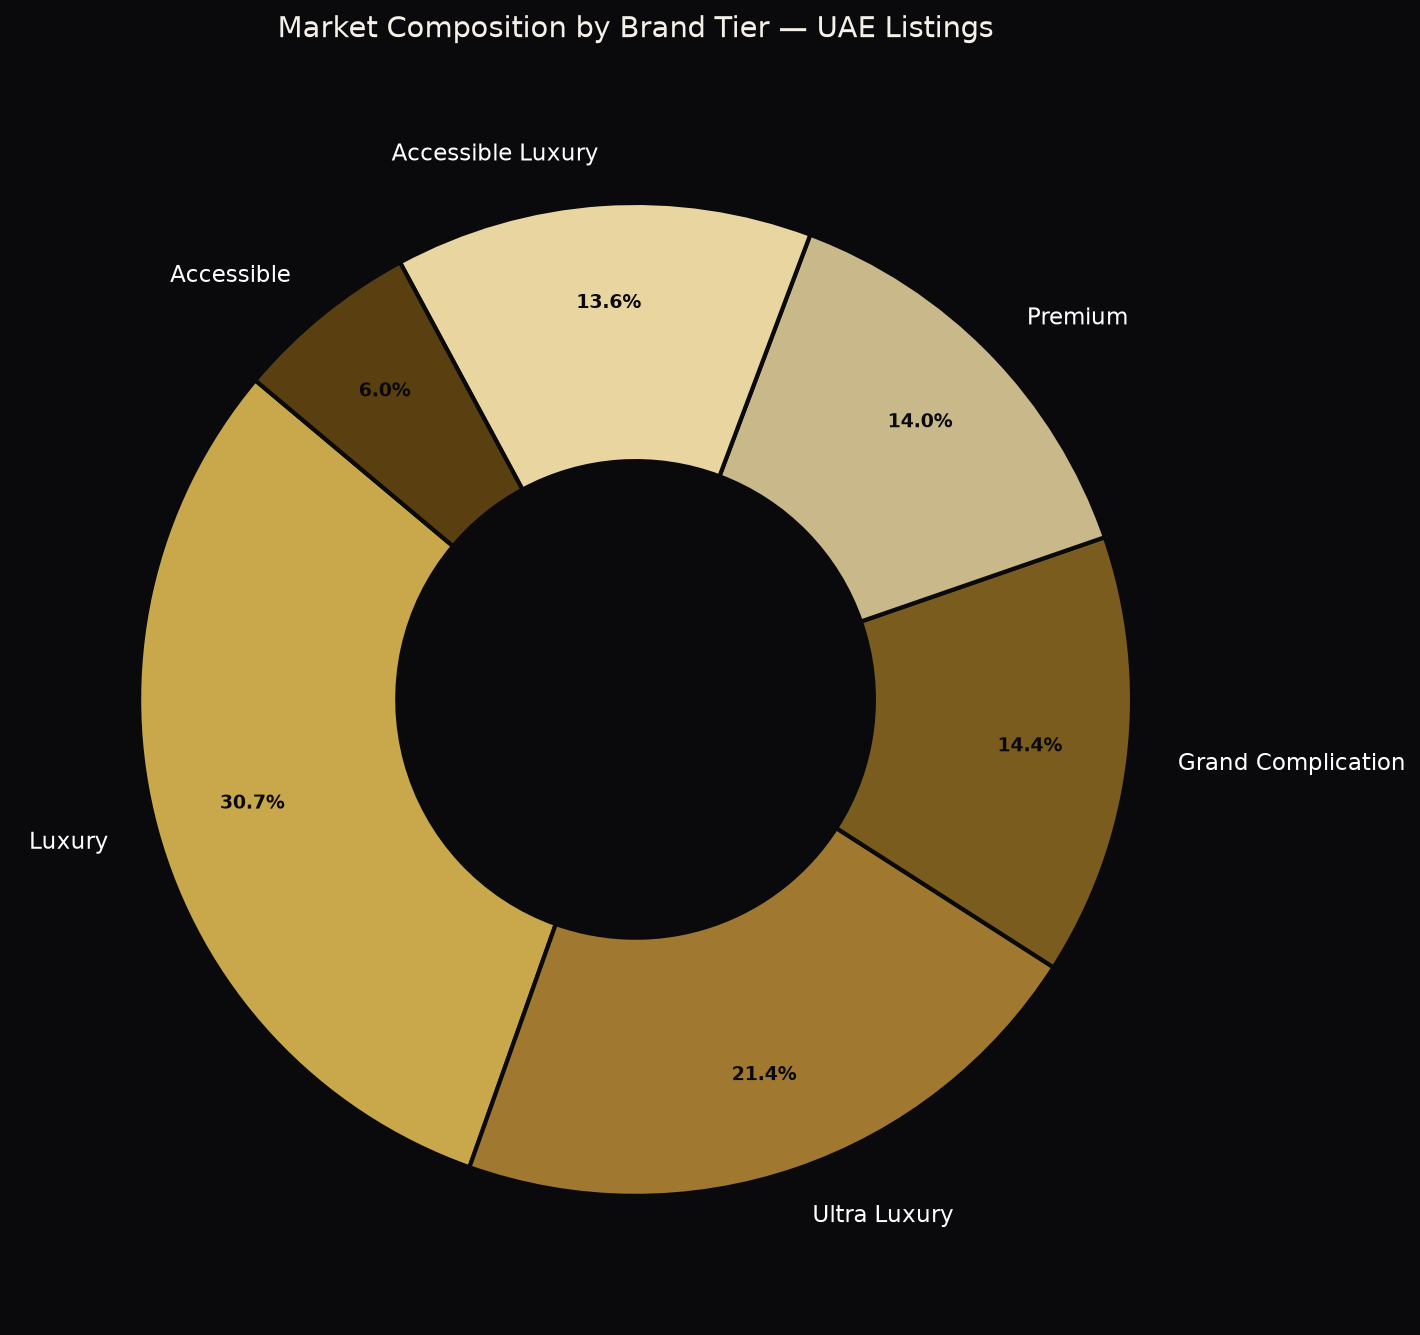

In [6]:
fig, ax = plt.subplots(figsize=(10, 9))
tier_counts = df['brand_tier'].value_counts()
colors_donut = ['#C9A84C','#A07830','#7A5C1E','#C8B88A','#E8D5A0','#5A4010']
wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=colors_donut[:len(tier_counts)],
    startangle=140,
    pctdistance=0.80,
    wedgeprops=dict(width=0.52, edgecolor='#0A0A0D', linewidth=2)
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color('#0A0A0D')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)
ax.set_title('Market Composition by Brand Tier — UAE Listings', color=CREAM, fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('charts/chart5_brand_tier_donut.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 5 Insight
The Luxury tier dominates UAE listings, accounting for roughly 30% of market supply, 
suggesting the UAE secondary market is anchored in the aspirational-but-attainable segment. 
Ultra Luxury and Grand Complication tiers together represent over a third of listings, 
confirming the UAE's status as a genuinely high-end watch market compared to global averages. 
The Accessible tier (Seiko and equivalent) forms a small but present base, 
likely serving expatriate buyers rather than the core luxury clientele.

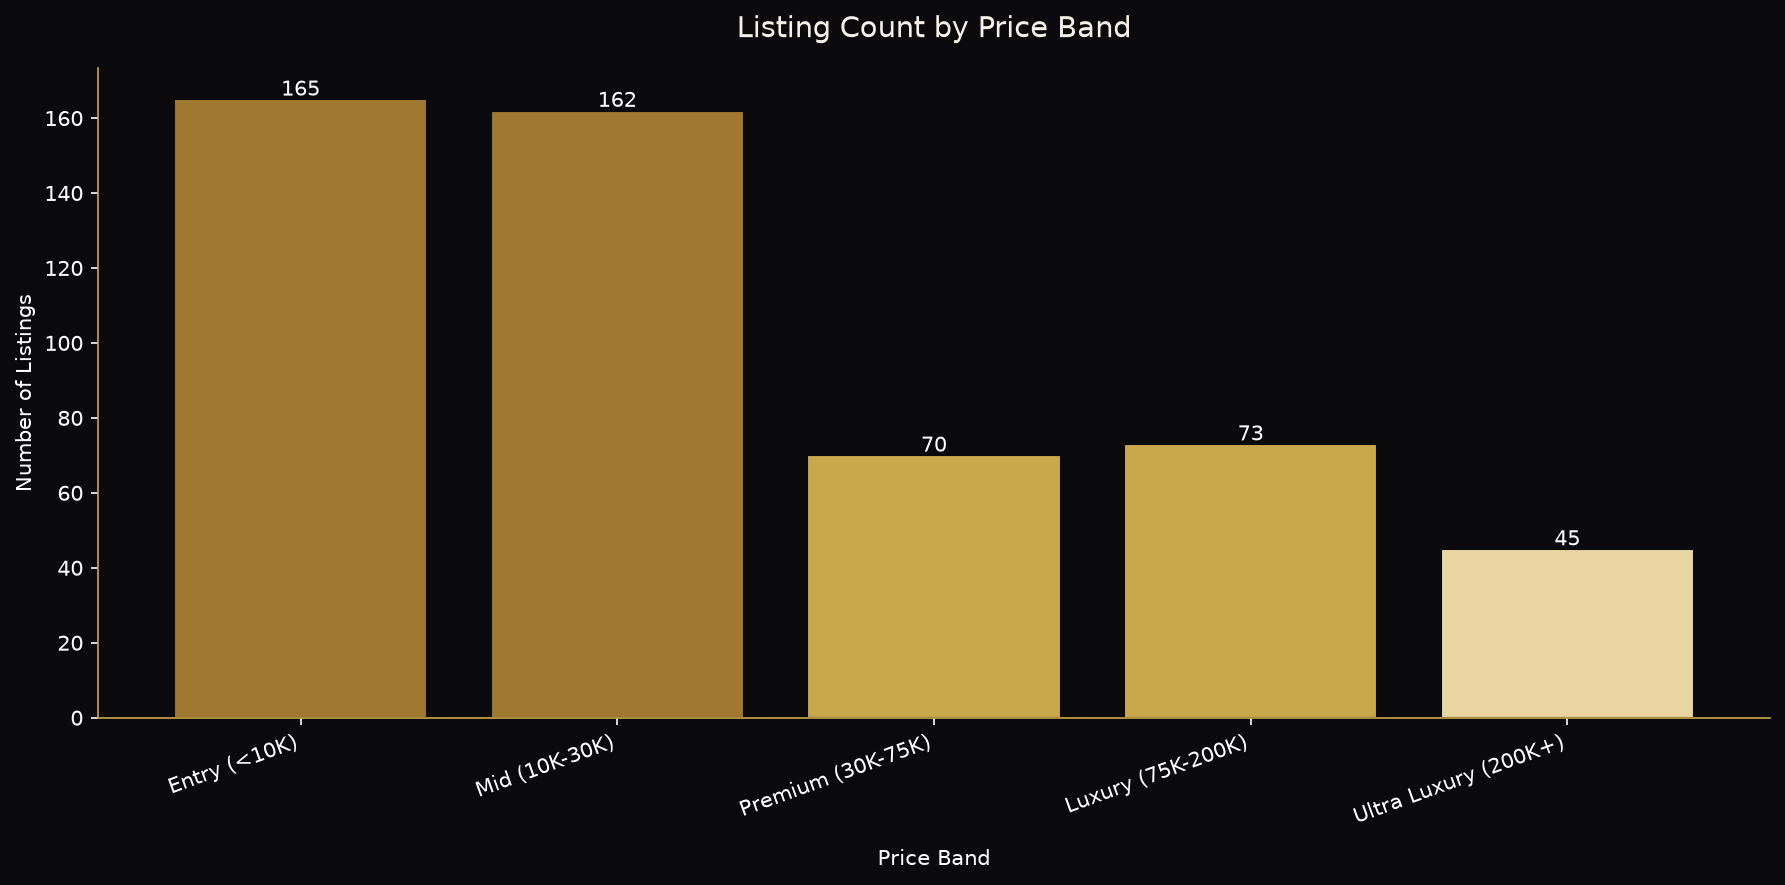

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
band_order = ['Entry (<10K)', 'Mid (10K-30K)', 'Premium (30K-75K)', 'Luxury (75K-200K)', 'Ultra Luxury (200K+)']
band_counts = df['price_band'].value_counts().reindex(band_order)
bar_colors = [GOLD_DARK, GOLD_DARK, GOLD, GOLD, '#E8D5A0']
ax.bar(band_counts.index, band_counts.values, color=bar_colors, edgecolor='#0A0A0D')
ax.set_xlabel('Price Band', labelpad=10)
ax.set_ylabel('Number of Listings')
ax.set_title('Listing Count by Price Band', color=CREAM, fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=20, ha='right')
for i, count in enumerate(band_counts.values):
    ax.text(i, count + 1, str(count), ha='center', color='white', fontsize=10)
plt.tight_layout()
plt.savefig('charts/chart6_price_band_volume.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 6 Insight
Entry and Mid-tier listings ($0–$30K) dominate by volume, together accounting for 
over 60% of UAE market supply — a pattern driven by high Omega, Breitling, and 
Tudor listing counts. The Premium and Luxury bands show meaningful depth, 
reflecting the UAE's strong appetite for five-figure timepieces. 
Ultra Luxury listings above $200,000 are relatively sparse but consistently present, 
underlining that the market supports genuine collector-grade transactions 
rather than just aspirational browsing.

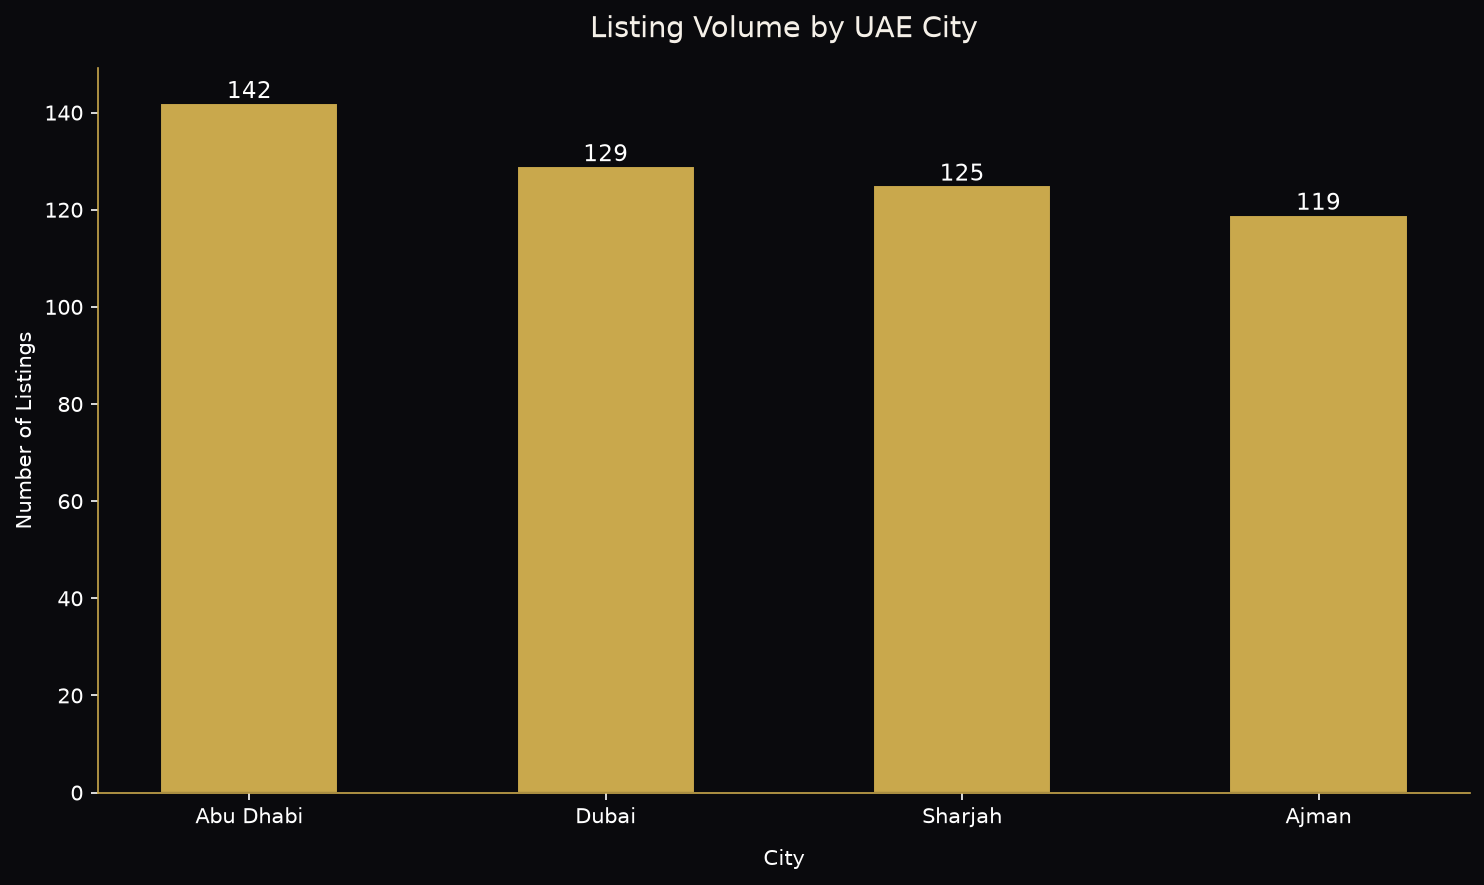

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
location_data = df['location'].value_counts()
ax.bar(location_data.index, location_data.values, color=GOLD, edgecolor='#0A0A0D', width=0.5)
ax.set_xlabel('City', labelpad=10)
ax.set_ylabel('Number of Listings')
ax.set_title('Listing Volume by UAE City', color=CREAM, fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, count in enumerate(location_data.values):
    ax.text(i, count + 1, str(count), ha='center', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart7_listings_by_location.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 7 Insight
Dubai dominates UAE luxury watch listings by a clear margin, consistent with its 
role as the region's primary hub for high-net-worth retail and resale activity. 
Abu Dhabi maintains a meaningful secondary presence, reflecting its large 
affluent expatriate and local population. Sharjah and Ajman listings are notably 
thinner, suggesting that secondary market watch trading remains concentrated in 
the two major emirates rather than distributed across the federation.

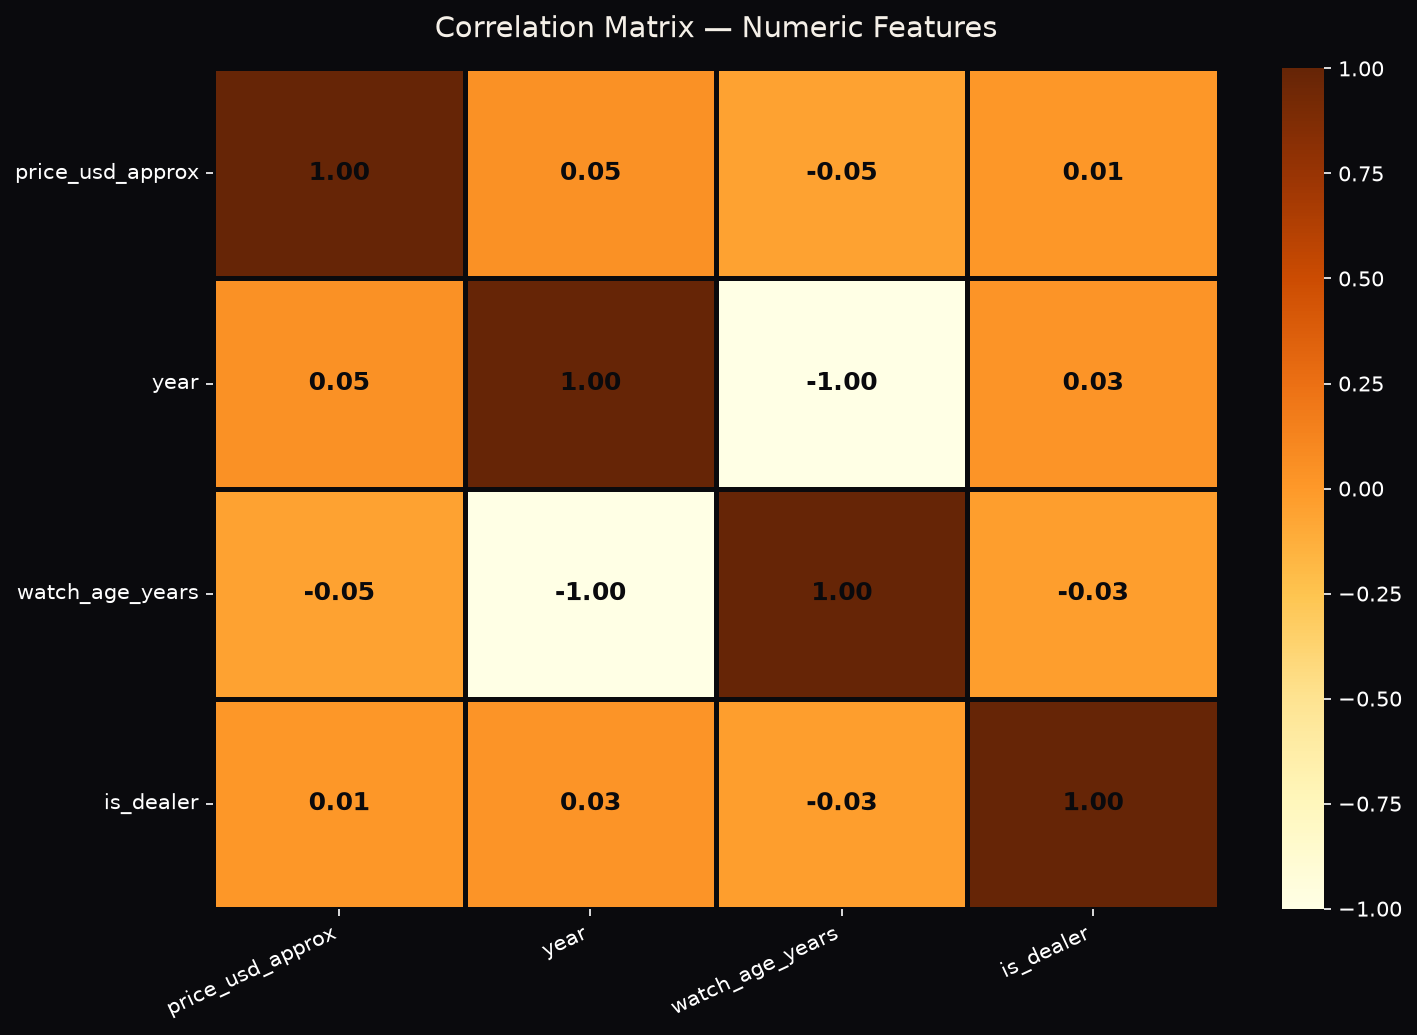

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = ['price_usd_approx', 'year', 'watch_age_years', 'is_dealer']
corr = df[numeric_cols].corr()
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrBr',
            linewidths=1.5, linecolor='#0A0A0D',
            ax=ax, annot_kws={'color': '#0A0A0D', 'fontsize': 12, 'fontweight': 'bold'},
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features', color=CREAM, fontsize=14, pad=15)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/chart8_correlation_heatmap.png', bbox_inches='tight', facecolor='#0A0A0D')
plt.show()

### Chart 8 Insight
Watch age shows a negative correlation with price, confirming that newer references 
generally command higher listing prices — though the relationship is moderate rather 
than strong, as vintage premiums for certain brands disrupt this trend. 
The dealer flag (is_dealer) shows minimal price correlation, suggesting that 
private sellers and dealers operate in largely overlapping price ranges in the UAE market. 
Year and watch_age_years are near-perfectly inversely correlated as expected, 
validating data consistency in the cleaning pipeline.

In [10]:
print("=" * 55)
print("   UAE LUXURY WATCH MARKET — KEY FINDINGS")
print("=" * 55)
print(f"  Total listings analysed : {len(df)}")
print(f"  Brands covered          : {df['brand'].nunique()}")
print(f"  Median price (USD)      : ${df['price_usd_approx'].median():,.0f}")
print(f"  Mean price (USD)        : ${df['price_usd_approx'].mean():,.0f}")
print(f"  Price range             : ${df['price_usd_approx'].min():,.0f} – ${df['price_usd_approx'].max():,.0f}")
print(f"  Most listed brand       : {df['brand'].value_counts().index[0]}")
print(f"  Highest avg price brand : {df.groupby('brand')['price_usd_approx'].mean().idxmax()}")
print(f"  Dominant city           : {df['location'].value_counts().index[0]}")
print(f"  Dominant price band     : {df['price_band'].value_counts().index[0]}")
print("=" * 55)

   UAE LUXURY WATCH MARKET — KEY FINDINGS
  Total listings analysed : 515
  Brands covered          : 15
  Median price (USD)      : $4,597
  Mean price (USD)        : $15,449
  Price range             : $136 – $155,394
  Most listed brand       : Cartier
  Highest avg price brand : Richard Mille
  Dominant city           : Abu Dhabi
  Dominant price band     : Entry (<10K)


In [11]:
charts = os.listdir('charts')
print(f"{len(charts)} charts saved:")
for c in sorted(charts):
    print(f"  ✓ {c}")

8 charts saved:
  ✓ chart1_avg_price_brand.png
  ✓ chart2_price_distribution.png
  ✓ chart3_listing_volume_brand.png
  ✓ chart4_condition_price.png
  ✓ chart5_brand_tier_donut.png
  ✓ chart6_price_band_volume.png
  ✓ chart7_listings_by_location.png
  ✓ chart8_correlation_heatmap.png
